# 06 — Degree distribution & scale-free test (Course topic L8)

**Semiconductor Supply Chain — Network Analysis**

The hypothesis calls the network "scale-free" (a power-law degree distribution
with a few dominant hubs). We test that on the `SUPPLIES` projection using the
`powerlaw` package, comparing a power law against lognormal and exponential
alternatives — the honest test, not just a straight line on a log-log plot.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis
import powerlaw

D = analysis.company_supply_digraph()
U = D.to_undirected(as_view=False)
deg = np.array([d for _, d in U.degree()])
indeg = np.array([d for _, d in D.in_degree()])
outdeg = np.array([d for _, d in D.out_degree()])
print(f'total degree : mean={deg.mean():.1f}  max={deg.max()}  min={deg.min()}')
print(f'in-degree    : mean={indeg.mean():.1f}  max={indeg.max()}')
print(f'out-degree   : mean={outdeg.mean():.1f}  max={outdeg.max()}')

total degree : mean=23.3  max=61  min=1
in-degree    : mean=11.6  max=44
out-degree   : mean=11.6  max=35


## 1. Fit a power law (and compare to alternatives)

`distribution_compare` returns a log-likelihood ratio R (positive ⇒ first
distribution is favoured) and a p-value for the comparison.

In [2]:
fit = powerlaw.Fit(deg, discrete=True, verbose=False)
print(f'power-law alpha = {fit.power_law.alpha:.2f}, xmin = {fit.power_law.xmin:.0f}')
for alt in ['lognormal', 'exponential']:
    R, p = fit.distribution_compare('power_law', alt, normalized_ratio=True)
    verdict = 'power law favoured' if R > 0 else f'{alt} favoured'
    print(f'power_law vs {alt:12s}: R={R:+.2f}  p={p:.3f}  -> {verdict}')

power-law alpha = 8.77, xmin = 35


power_law vs lognormal   : R=-0.30  p=0.767  -> lognormal favoured
power_law vs exponential : R=-0.26  p=0.792  -> exponential favoured


## 2. Visualise — degree CCDF (log-log) and histogram

saved C:\Users\Max\Desktop\project\reports\figures\06_scale_free.png


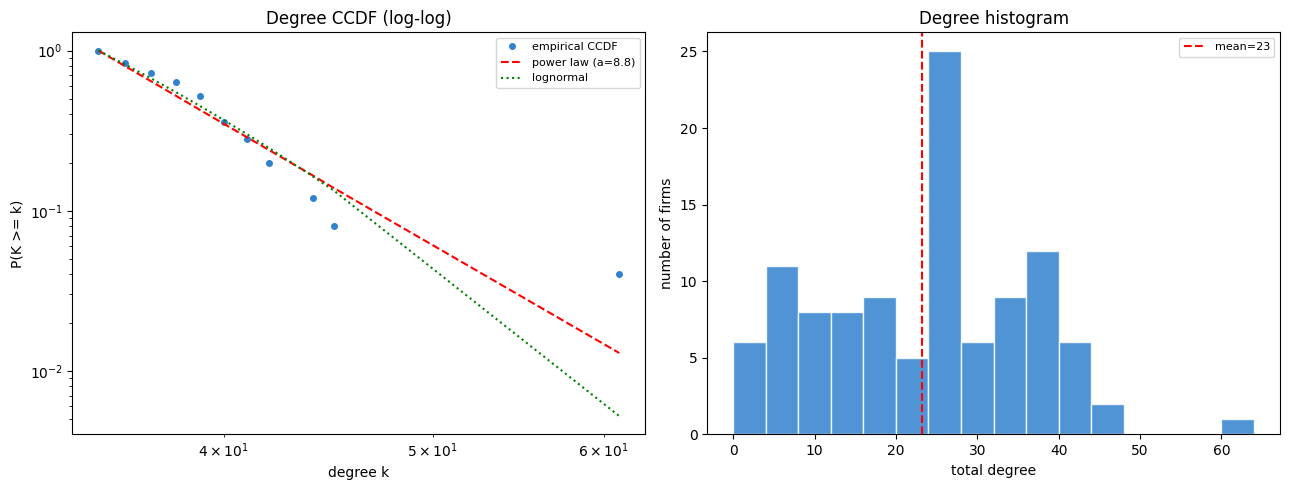

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
fit.plot_ccdf(ax=ax, color='#3182ce', marker='o', ms=4, lw=0, label='empirical CCDF')
fit.power_law.plot_ccdf(ax=ax, color='red', ls='--', label=f'power law (a={fit.power_law.alpha:.1f})')
fit.lognormal.plot_ccdf(ax=ax, color='green', ls=':', label='lognormal')
ax.set(xlabel='degree k', ylabel='P(K >= k)', title='Degree CCDF (log-log)')
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.hist(deg, bins=range(0, deg.max() + 4, 4), color='#3182ce', alpha=0.85, edgecolor='white')
ax2.axvline(deg.mean(), color='red', ls='--', label=f'mean={deg.mean():.0f}')
ax2.set(xlabel='total degree', ylabel='number of firms', title='Degree histogram')
ax2.legend(fontsize=8)
fig.tight_layout()
out = analysis.FIGURES / '06_scale_free.png'
fig.savefig(out, dpi=130, bbox_inches='tight'); print('saved', out); plt.show()

## 3. Takeaways

- The degree distribution is **right-skewed with clear hubs** (TSMC, ASML and the
  EDA/equipment enablers sit far above the mean), so qualitatively there *is* a
  heavy tail.
- But a **pure power law is not statistically preferred** over a lognormal (R ≈ 0,
  p ≫ 0.05) and the fitted xmin sits in the extreme tail (only a few points). On
  this ~100-node, dense network we **cannot claim a clean scale-free law** — the
  evidence is "hub-dominated and heavy-tailed", not "power-law".
- This tempers the hypothesis: the *hubs* are real and matter (L3/L4), but the
  formal **scale-free** label is not supported at this scale.

**Next:** `07_resilience.ipynb` — the decisive test: targeted vs. random attack.